In [2]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [4]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251219-000823'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [5]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [6]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

In [294]:
# Assume df has columns: ['i', 'cs_j', 'richness']

# For each group (e.g., by 'i'), compute the conditional probability
pivot = df.pivot_table(index='i', columns='cs_j', values='richness', aggfunc='mean')
results = []
for cs_j in range(1, 7):
    for richness in range(5):
        mask_n0 = (pivot.loc[:, :cs_j-1] == richness).all(axis=1)
        mask_n = (pivot.loc[mask_n0, cs_j] == richness)
        # gdf = df.loc[mask_n0].groupby('i').mean().reset_index()
        # # idxs = gdf.loc[gdf.richness == richness, 'i'].values
        # mask_n = (df['cs_j'] == cs_j) & (df['richness'] == richness)& (df['i'].isin(idxs))
        
        n = mask_n.sum()
        # n_total = len(idxs)
        n_total = mask_n0.sum()
        results.append([cs_j, richness, n, n_total])
        total_n = (df['cs_j'] == cs_j).sum()
        
cond_prob_df = pd.DataFrame(results, columns= ['cs_j', 'richness', 'n', 'n_total'])

In [295]:
cond_prob_df['P'] = cond_prob_df['n'] / cond_prob_df['n_total']

In [298]:
cond_prob_df.loc[cond_prob_df.richness == 4]

,cs_j,richness,n,n_total,P
4,1,4,283,1166,0.242710
9,2,4,121,283,0.427562
14,3,4,50,121,0.413223
19,4,4,18,50,0.360000
24,5,4,9,18,0.500000
29,6,4,7,9,0.777778


In [299]:
agg_df = cond_prob_df.groupby('cs_j').sum()
agg_df['P'] = agg_df['n'] / agg_df['n_total']

In [300]:
agg_df

,richness,n,n_total,P
cs_j,,,,
1,10,3856,10000,0.385600
2,10,1792,3856,0.464730
3,10,869,1792,0.484933
4,10,443,869,0.509781
5,10,231,443,0.521445
6,10,144,231,0.623377


In [308]:


cols = [0, 1, 2, 3, 4, 5, 6]
pivot_arr = pivot[cols].to_numpy()
all_probs = []
all_cols = []
for k, perm in enumerate(itertools.permutations(range(len(cols)))):
    arr = pivot_arr[:, perm]
    # Do first cs for j=1,2,3,4
    probjs = []
    for j in [1,2,3,4]:
        prob_j = (arr[:, 0]==j).sum()/len(arr)
        probjs.append(prob_j)
    all_probs.append([k, np.nan]+probjs)
    all_cols.append(tuple([perm[0]]))
    for i in range(1, len(cols)):
        probs = [k]
        probjs = []
        prev_mask = arr[:, :i].std(axis=1)==0
        if prev_mask.sum() == 0:
            probs.append(np.nan)
        else:
            this_mask = arr[:, :i+1].std(axis=1)==0
            prob = this_mask.sum()/prev_mask.sum()
            probs.append(prob)
        

        for j in [1,2,3,4]:
            prev_mask = (arr[:, :i]==j).all(axis=1)
            if prev_mask.sum() == 0:
                prob_j = np.nan
            else:
                this_mask = (arr[prev_mask, i]==j)#.all(axis=1)
                prob_j = this_mask.sum()/prev_mask.sum()
            probjs.append(prob_j)

        all_cols.append(perm[:i+1])
        all_probs.append(probs+probjs)

    # Optional: break after N for testing
    # if len(all_probs) >= 100:
    #     break

In [ ]:
# j_cols = [f'{i}_S{j}' for i in range(0, len(cols)) for j in [1,2,3,4]]

In [309]:
probdf = pd.DataFrame(all_probs, columns=['Permutation', 'Any', 'R1', 'R2', 'R3', 'R4'])

In [310]:
cols_df = pd.DataFrame({'Columns': all_cols})
cols_df["N_CS"] = cols_df['Columns'].apply(len)

In [311]:
probdf2 = pd.merge(probdf, cols_df, left_index=True, right_index=True)

In [312]:
probdf2.drop_duplicates(inplace=True, subset=['Columns'])

In [313]:
probdf2L = probdf2.melt(id_vars=['Permutation', 'Columns', 'N_CS'], value_vars=['Any', 'R1', 'R2', 'R3', 'R4'], var_name='Richness', value_name='Probability')

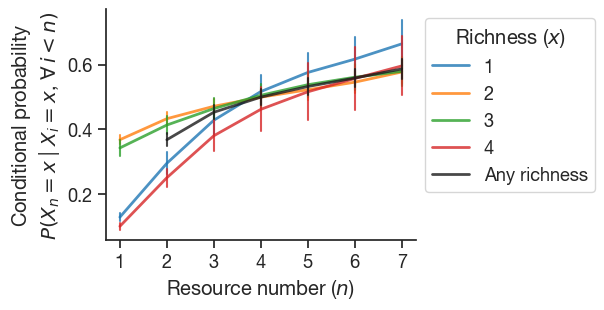

In [315]:
fig, ax = plt.subplots(figsize=(4,3))
colors = sns.color_palette("tab10", n_colors=4)
palette = {'Any': 'k', 'R1': colors[0], 'R2': colors[1], 'R3': colors[2], 'R4': colors[3]}
l = sns.lineplot(probdf2L, x='N_CS', y='Probability', hue='Richness', errorbar='sd', err_style='bars', 
ax = ax, palette=palette, alpha=0.8, lw = 2, hue_order=['R1', 'R2', 'R3', 'R4', 'Any'])  # Move 'Any' to front)



sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel(r'Resource number ($n$)')
ax.set_ylabel(r'Conditional probability$\,$' + '\n' + r'$P(X_n = x$ | $X_i = x$, $\forall \, i < n)$')

new_labels = {
    'Any': 'Any richness',
    'R1': '1',
    'R2': '2',
    'R3': '3',
    'R4': '4'
}
handles, labels = ax.get_legend_handles_labels()
labels = [new_labels.get(label, label) for label in labels]
ax.legend(handles, labels, title="Richness ($x$)", loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(range(1,8))
plt.savefig(figure_folder / 'cs_screen_conditional_probability.pdf', bbox_inches='tight')
